In [43]:
import argparse

def list_of_ints(arg):
    return list(map(int, arg.split(',')))

parser = argparse.ArgumentParser(
    description="Train or evaluate NeurWP models for LAM"
)
parser.add_argument(
    "--data_config",
    type=str,
    default="neural_lam/data_config.yaml",
    help="Path to data config file (default: neural_lam/data_config.yaml)",
)
parser.add_argument(
    "--model",
    type=str,
    default="graph_lam",
    help="Model architecture to train/evaluate (default: graph_lam)",
)
parser.add_argument(
    "--subset_ds",
    action="store_true",
    help="Use only a small subset of the dataset, for debugging"
    "(default: false)",
)
parser.add_argument(
    "--seed", type=int, default=42, help="random seed (default: 42)"
)
parser.add_argument(
    "--n_workers",
    type=int,
    default=4,
    help="Number of workers in data loader (default: 4)",
)
parser.add_argument(
    "--epochs",
    type=int,
    default=200,
    help="upper epoch limit (default: 200)",
)
parser.add_argument(
    "--batch_size", type=int, default=4, help="batch size (default: 4)"
)
parser.add_argument(
    "--load",
    type=str,
    help="Path to load model parameters from (default: None)",
)
parser.add_argument(
    "--restore_opt",
    action="store_true",
    help="If optimizer state should be restored with model "
    "(default: false)",
)
parser.add_argument(
    "--precision",
    type=str,
    default=32,
    help="Numerical precision to use for model (32/16/bf16) (default: 32)",
)
parser.add_argument(
    "--num_sanity_steps",
    type=int,
    default=2,
    help="Number of sanity checking validation steps to run before starting"
    " training (default: 2)",
)

# Model architecture
parser.add_argument(
    "--graph",
    type=str,
    default="multiscale",
    help="Graph to load and use in graph-based model "
    "(default: multiscale)",
)
parser.add_argument(
    "--diffusion_model",
    type=str,
    default="edm",
    help="Model to use in the diffusion model"
    "(default: edm)",
)
parser.add_argument(
    "--hidden_dim",
    type=int,
    default=128,
    help="Dimensionality of all hidden representations (default: 64)",
)
parser.add_argument(
    "--latent_dim",
    type=int,
    default=None,
    help="Dimensionality of latent R.V. at each node (if different than"
    " hidden_dim) (default: None (same as hidden_dim))",
)
parser.add_argument(
    "--hidden_layers",
    type=int,
    default=1,
    help="Number of hidden layers in all MLPs (default: 1)",
)
parser.add_argument(
    "--processor_layers",
    type=int,
    default=6,
    help="Number of GNN layers in processor GNN (for prob. model: in "
    "decoder) (default: 6)",
)
parser.add_argument(
    "--encoder_processor_layers",
    type=int,
    default=1,
    help="Number of on-mesh GNN layers in encoder GNN (default: 2)",
)
parser.add_argument(
    "--prior_processor_layers",
    type=int,
    default=1,
    help="Number of on-mesh GNN layers in prior GNN (default: 2)",
)
parser.add_argument(
    "--mesh_aggr",
    type=str,
    default="sum",
    help="Aggregation to use for m2m processor GNN layers (sum/mean) "
    "(default: sum)",
)
parser.add_argument(
    "--output_std",
    action="store_true",
    help="If models should additionally output std.-dev. per "
    "output dimensions "
    "(default: False (no))",
)
parser.add_argument(
    "--shared_grid_embedder",
    action="store_true",  # Default to separate embedders
    help="If the same embedder MLP should be used for interior and boundary"
    " grid nodes. Note that this requires the same dimensionality for "
    "both kinds of grid inputs. (default: False (no))",
)
parser.add_argument(
    "--prior_dist",
    type=str,
    default="isotropic",
    help="Structure of Gaussian distribution in prior network output "
    "(isotropic/diagonal) (default: isotropic)",
)
parser.add_argument(
    "--learn_prior",
    type=int,
    default=1,
    help="If the prior should be learned as a mapping from previous state "
    "and forcing, otherwise static with mean 0 (default: 1 (yes))",
)
parser.add_argument(
    "--vertical_propnets",
    type=int,
    default=0,  # TODO: Change to 1 as it is used in the paper
    help="If PropagationNets should be used for all vertical message "
    "passing (g2m, m2g, up in hierarchy), in deterministic models."
    "(default: 0 (no))",
)
parser.add_argument(
    "--sampler",
    type=str,
    default="heun",
    help="The sampler to use when generating trajectories with a diffusion model"
    "(heun/edm) (default: heun)",
)

# Training options
parser.add_argument(
    "--ar_steps",
    type=int,
    default=1,
    help="Number of steps to unroll prediction for in loss (1-19) "
    "(default: 1)",
)
parser.add_argument(
    "--control_only",
    action="store_true",
    help="Train only on control member of ensemble data "
    "(default: False)",
)
parser.add_argument(
    "--loss",
    type=str,
    default="wmse",
    help="Loss function to use, see metric.py (default: wmse)",
)
parser.add_argument(
    "--step_length",
    type=int,
    default=3,
    help="Step length in hours to consider single time step 1-3 "
    "(default: 3)",
)
parser.add_argument(
    "--lr", type=float, default=1e-3, help="learning rate (default: 0.001)"
)
parser.add_argument(
    "--val_interval",
    type=int,
    default=1,
    help="Number of epochs training between each validation run "
    "(default: 1)",
)
parser.add_argument(
    "--kl_beta",
    type=float,
    default=1.0,
    help="Beta weighting in front of kl-term in ELBO (default: 1)",
)
parser.add_argument(
    "--crps_weight",
    type=float,
    default=0,
    help="Weighting for CRPS term of loss, not computed if = 0. CRPS is "
    "computed based on trajectories sampled using prior distribution. "
    "(default: 0)",
)
parser.add_argument(
    "--sample_obs_noise",
    type=int,
    default=0,
    help="If observation noise should be sampled during rollouts (both "
    "training and eval), or just mean prediction used "
    "(default: 0 (no))",
)
parser.add_argument(
    "--border_condition",
    action="store_true",
    help="If border condition should be used in diffusion model ",
)

parser.add_argument(
    "--pred_residual",
    action="store_true",
    help="If the model should predict residuals instead of absolute values",
)
parser.add_argument(
    "--weight_decay",
    type=float,
    default=0.01,
    help="Weight decay for training. (default: 0.01)",
)
parser.add_argument(
    "--lr_scheduler",
    type=str,
    help="Learning rate scheduler to use, supported (cosine), (default: None)",
)
parser.add_argument(
    "--sigma_min",
    type=float,
    default=0.002,
    help="Sigma min for training. (default: 0.002)",
)
parser.add_argument(
    "--sigma_max",
    type=float,
    default=88,
    help="Sigma min for training. (default: 88)",
)
parser.add_argument(
    "--sigma_coef",
    type=float,
    default=1,
    help="Sigma coefficient for stochatic interpolants (default: 1)",
)

# EDM Options
parser.add_argument(
    "--resample_filter",
    type=list_of_ints,
    default="1,1",
    help="Resample filter for edm model (default: 1,1 or 1,3,3,1)",
)
parser.add_argument(
    "--channel_mult",
    type=list_of_ints,
    default="1,2,2,2",
    help="Channel multiplier for edm model (depth and width of UNET) (default: 1,2,2,2)",
)

parser.add_argument(
    "--encoder_type",
    type=str,
    default="standard",
    help="Type of encoder to use in edm model (standard/residual/skip)"
    "(default: 'standard')",
)

parser.add_argument(
    "--attn_resolutions",
    type=list_of_ints,
    default="1",
    help="Resolutions to apply attention to in edm model (default: '1')",
)

parser.add_argument(
    "--noise_embedding",
    type=str,
    default="fourier",
    help="Type of encoder to use in edm model (positional/fourier)"
    "(default: 'fourier')",
)

# CRPS Options
parser.add_argument(
    "--noise_dim",
    type=int,
    default=32,
    help="Dimension of the noise vector z, 32 in FGN (default: 32)",
)

# Evaluation options
parser.add_argument(
    "--eval",
    type=str,
    help="Eval model on given data split (val/test) "
    "(default: None (train model))",
)
parser.add_argument(
    "--n_example_pred",
    type=int,
    default=1,
    help="Number of example predictions to plot during val/test "
    "(default: 1)",
)
parser.add_argument(
    "--ensemble_size",
    type=int,
    default=5,
    help="Number of ensemble members during evaluation (default: 5)",
)
parser.add_argument(
    "--sampler_steps",
    type=int,
    default=20,
    help="Number of sampling steps during inference (default: 20)",
)
parser.add_argument(
    "--plot_diffusion_steps",
    action="store_true",
    help="If the diffusion steps should be saved, only one time step is saved",
)
parser.add_argument(
    "--noise_aug_prob",
    type=float,
    default=0,
    help="Probability of noise augmentation for training (default: 0)",
)
parser.add_argument(
    "--save_output",
    action="store_true",
    help="If the model output should be saved to the output folder (default: False)",
)
parser.add_argument(
    "--save_steps",
    action="store_true",
    help="If the model output should be saved to the output folder (default: False)",
)

# tEDM Options
parser.add_argument(
    "--v",
    type=float,  # TODO: Could be tensor with different values for each variable
    default=3.0,  # 3, 5 in the paper
    # NOTE: Heavier tails for lower v, gaussian for v -> ∞
    help="v > 2 parameter for tEDM (default: 3)",
)

# Logger Settings
parser.add_argument(
    "--wandb_project",
    type=str,
    default="neural-lam_prob",
    help="Wandb run project (default: 'neural-lam_prob')",
)
parser.add_argument(
    "--wandb_run_name",
    type=str,
    default="",
    help="Wandb run name (default: '')",
)
parser.add_argument(
    "--val_steps_to_log",
    type=list,
    default=[1, 2, 3, 5, 10, 15, 19],
    help="Steps to log val loss for (default: [1, 2, 3, 5, 10, 15, 19])",
)
parser.add_argument(
    "--metrics_watch",
    nargs="+",
    default=[],
    help="List of metrics to watch, including any prefix (e.g. val_rmse)",
)
parser.add_argument(
    "--var_leads_metrics_watch",
    type=str,
    default="{}",
    help="""JSON string with variable-IDs and lead times to log watched
            metrics (e.g. '{"1": [1, 2], "3": [3, 4]}')""",
)
parser.add_argument(
    "--save_output_wandb",
    action="store_true",
    help="If the model output should be saved to wandb (save_output has to be enabled)",
)

args = parser.parse_args([])

In [44]:
import torch
from neural_lam.weather_dataset import WeatherDataset

# if you change the seed, make sure that the randomly-applied transforms
# properly show that the image can be both transformed and *not* transformed!
torch.manual_seed(42)
standardize = True
args.pred_length = 5

dataset = WeatherDataset(
            "meps",
            pred_length=args.pred_length,
            split="test",
            subsample_step=3,
            subset=bool(1),
            control_only=0,
            standardize=standardize,
            border_condition=True
        )

sample_idx = 0 # torch.randint(len(dataset), size=(1,)).item()
(init_states, target_states, forcing, boundary_forcing) = dataset[sample_idx]

print(f"init_states shape: {init_states.shape}")
print(f"target_states shape: {target_states.shape}")
print(f"forcing shape: {forcing.shape}")
print(f"boundary_forcing shape: {boundary_forcing.shape}")

Loading sample from /proj/berzelius-2022-164/weather/neural_lam_datasets/meps/samples/test/nwp_2022070400_mbr000.npy
Sample name: 2022070400_mbr000
index: 0
init_states shape: torch.Size([2, 54064, 17])
target_states shape: torch.Size([5, 54064, 17])
forcing shape: torch.Size([5, 54064, 16])
boundary_forcing shape: torch.Size([5, 9720, 67])


/proj/berzelius-2022-164/users/x_erila/neural-lam/neural_lam/utils.py:24: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  return torch.load(
/proj/berzelius-2022-164/users/x_e

In [45]:
len(dataset)

1

In [46]:
from neural_lam import utils, config

static_data_dict = utils.load_static_data("meps")
data_config = config.Config.from_file("neural_lam/data_config.yaml")

# for key, value in static_data_dict.items():
#     print(f"{key}: {value}")

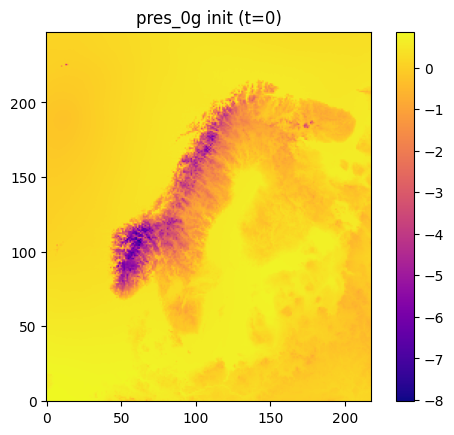

In [47]:
import matplotlib.pyplot as plt
import os
GRID_SHAPE = (248, 218)  # (y, x) without border
FULL_GRID_SHAPE = (268, 238)
VAR_IDX = 0

time_idx = 0  # choose which timestep to plot
output_dir = "./state_debug_OG"
if standardize:
    output_dir += "_standardized"
os.makedirs(output_dir, exist_ok=True)
for var_idx, var_name in enumerate(data_config.dataset.var_names):
    # init_states assumed shape (T, N, V) -> reshape to (T, Y, X, V)
    # arranged = init_states.reshape(init_states.shape[0], GRID_SHAPE[0], GRID_SHAPE[1], -1)
    if var_idx == VAR_IDX:
        arranged = target_states.reshape(target_states.shape[0], GRID_SHAPE[0], GRID_SHAPE[1], -1)

        img = arranged[time_idx, ..., var_idx]
        torch.save(img, os.path.join(output_dir, f"MEPS_OG_{var_name}_init_t{time_idx}.pt"))
        img = img.cpu().numpy() if hasattr(img, "cpu") else img.numpy()

        plt.figure()
        plt.imshow(img, cmap="plasma", origin="lower")
        plt.title(f"{var_name} init (t={time_idx})")
        plt.colorbar()
        plt.savefig(os.path.join(output_dir, f"MEPS_OG_{var_name}_init_t{time_idx}.png"))

# Assimilation

In [48]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
args.device = device
args.pred_residual = True
args.border_condition = True

args.obs_sigma=3.0
args.obs_p=0.25
args.ensemble_size=5

args.num_ess_samples = 1
args.max_subiter = 100
args.num_ess_warmup = 100

args.pretrained_model_path = "/proj/berzelius-2022-164/users/x_erila/neural-lam/saved_models/CRPS_AR2_1200e-CRPS-6x128-09_25_10-4226/last_epoch-v199.ckpt"

In [49]:
from neural_lam.models.crps import CRPS

# Get prior
model = CRPS(args).to(args.device)
model.load_state_dict(torch.load(args.pretrained_model_path,map_location=args.device)["state_dict"])
model.eval()
# Scale and normalize init_states
init_states_ens = init_states.unsqueeze(0).expand(args.ensemble_size, -1, -1, -1).contiguous().to(device)
forcing_ens = forcing.unsqueeze(0).expand(args.ensemble_size, -1, -1, -1).contiguous().to(device)
boundary_forcing_ens = boundary_forcing.unsqueeze(0).expand(args.ensemble_size, -1, -1, -1).contiguous().to(device)

print("init_states_ens.shape (should be [n_ens, time, n_grid, d]):", init_states_ens.shape)


priors = []
with torch.no_grad():
    for i in range(target_states.shape[0]):
        # init_z = torch.randn(
        #     init_states_ens.shape[0], model.model.noise_dim, device=args.device)
        
        prev_prev_state = init_states_ens[:, 0]
        prev_state = init_states_ens[:, 1]
        prior, _ = model.predict_step(
                            prev_state, prev_prev_state, forcing_ens[:, i], boundary_forcing_ens[:, i])
        priors.append(prior)
        init_states_ens = torch.cat([init_states_ens[:, 1:], prior.unsqueeze(1)], dim=1)

prior = torch.stack(priors, dim=0)


grid_dim: 54
Attn at level 0 with res 268: False
Attn at level 0 with res 268: False
Attn at level 0 with res 268: False
Attn at level 0 with res 268: False
Channels at level 0: 128
res_down: tensor([134, 120], dtype=torch.int32)
Attn at level 1 with res 134: False
Attn at level 1 with res 134: False
Attn at level 1 with res 134: False
Attn at level 1 with res 134: False
Channels at level 1: 256
res_down: tensor([68, 60], dtype=torch.int32)
Attn at level 2 with res 68: False
Attn at level 2 with res 68: False
Attn at level 2 with res 68: False
Attn at level 2 with res 68: False
Channels at level 2: 256
res_down: tensor([34, 30], dtype=torch.int32)
Attn at level 3 with res 34: False
Attn at level 3 with res 34: False
Attn at level 3 with res 34: False
Attn at level 3 with res 34: False
Channels at level 3: 256
res_up: tensor([68, 60], dtype=torch.int32)
res_up: tensor([134, 120], dtype=torch.int32)
res_up: tensor([268, 238], dtype=torch.int32)


/tmp/ipykernel_30361/3574132288.py:5: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(args.pretrained_model_path,map_location=args.device)["st

init_states_ens.shape (should be [n_ens, time, n_grid, d]): torch.Size([5, 2, 54064, 17])


## Interpolating between two latent variables

In [50]:
z0 = torch.randn(init_states_ens.shape[0], model.model.noise_dim, device=args.device)
z1 = torch.randn(init_states_ens.shape[0], model.model.noise_dim, device=args.device)

print("Noise diff: ", torch.mean(torch.abs(z0 - z1), dim=-1))

init_states_ens = init_states.unsqueeze(0).expand(args.ensemble_size, -1, -1, -1).contiguous().to(device)
prev_prev_state = init_states_ens[:, 0]
prev_state = init_states_ens[:, 1]

with torch.no_grad():
    z0_pred, _ = model.predict_step(
                        prev_state, prev_prev_state, forcing_ens[:, 0], boundary_forcing_ens[:, 0], z=z0)
    z1_pred, _ = model.predict_step(
                        prev_state, prev_prev_state, forcing_ens[:, 0], boundary_forcing_ens[:, 0], z=z1)
    
K = 5
alphas = torch.linspace(0.0, 1.0, K, device=z0.device)                # (K,)

# z0, z1 shape: (n_ens, D)
# build z_interp shape: (K, n_ens, D)
z_interp = (1.0 - alphas).view(K, 1, 1) * z0.unsqueeze(0) + alphas.view(K, 1, 1) * z1.unsqueeze(0)

zk_preds = []   
model.eval()
with torch.no_grad():
    for k in range(K):
        z_k = z_interp[k].to(device)                # ensure on correct device
        pred_k, _ = model.predict_step(prev_state, prev_prev_state,
                                       forcing_ens[:, 0], boundary_forcing_ens[:, 0], z=z_k)
        # move result to CPU and detach to free GPU memory
        zk_preds.append(pred_k)
        # free GPU memory used by pred_k / z_k
        del pred_k, z_k
        torch.cuda.empty_cache()
# stack on CPU: shape (K, n_ens, ...)
zk_preds = torch.stack(zk_preds, dim=0)

Noise diff:  tensor([1.1925, 1.2075, 0.9046, 1.1074, 1.1066], device='cuda:0')


In [51]:
z0_pred.shape, z1_pred.shape, zk_preds.shape

(torch.Size([5, 54064, 17]),
 torch.Size([5, 54064, 17]),
 torch.Size([5, 5, 54064, 17]))

In [52]:
target_states.shape

torch.Size([5, 54064, 17])

In [53]:
((z0_pred[0, :, 6] - target_states[0, :, 6].to(device))**2).mean().sqrt()

tensor(0.0681, device='cuda:0')

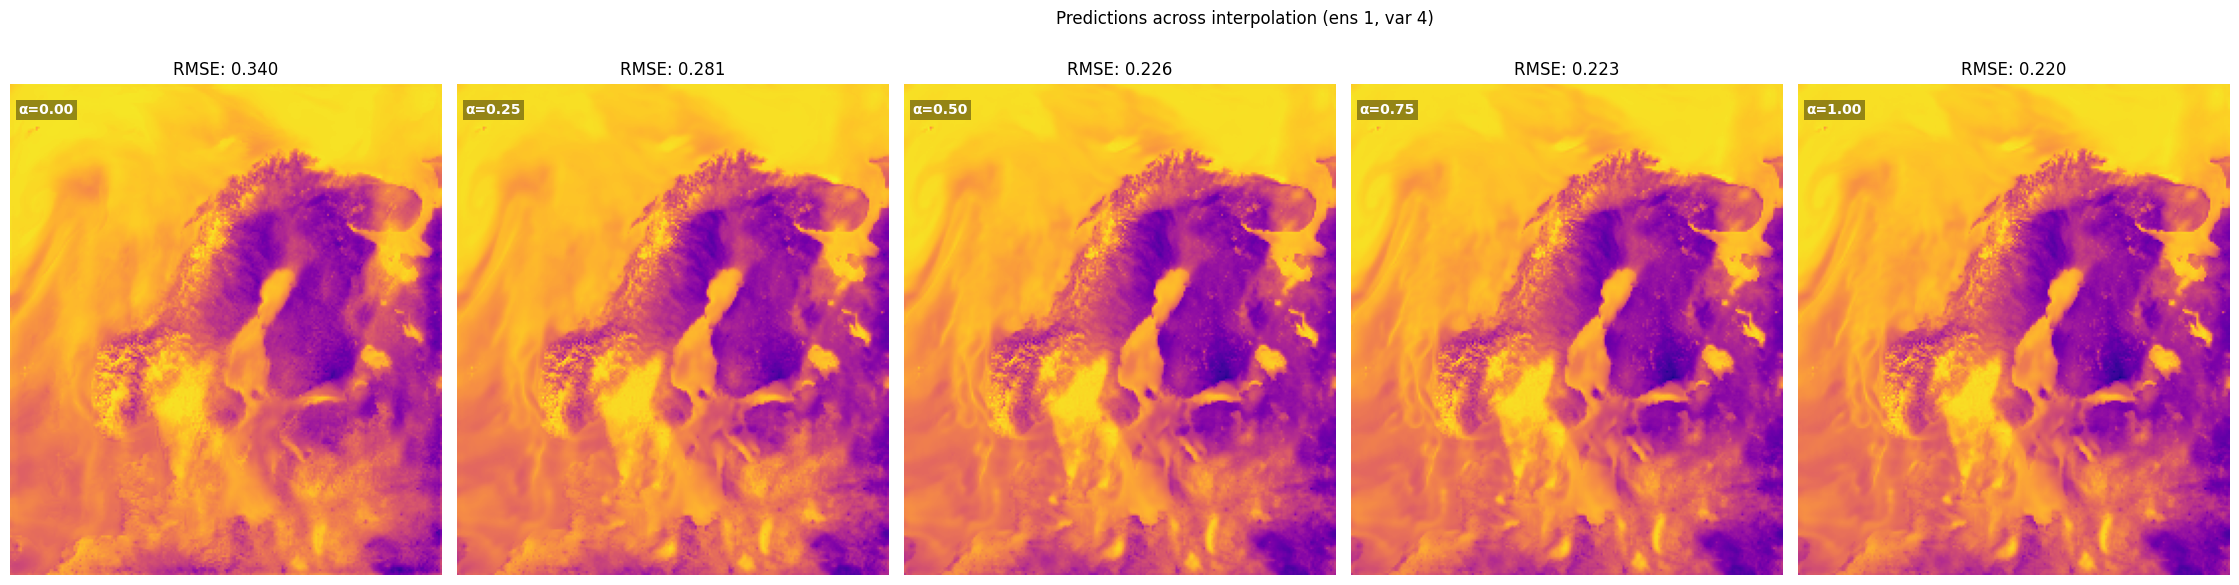

In [71]:
import matplotlib.pyplot as plt
import numpy as np

# choose which ensemble member and variable (channel) to visualize
ens_idx = 1        # 0..args.ensemble_size-1
var_idx = 4        # 0..(state_dim-1)
K = zk_preds.shape[0]

# ensure CPU numpy arrays
zk_np = zk_preds.cpu().numpy()        # shape (K, n_ens, N, V)
alphas_np = alphas.cpu().numpy() if isinstance(alphas, torch.Tensor) else np.linspace(0,1,K)

# grid shape used earlier
H, W = GRID_SHAPE    # GRID_SHAPE defined earlier in notebook (248, 218)
assert zk_np.shape[2] == H * W, "expected flattened grid matching GRID_SHAPE"

# compute consistent color scale across all alphas for this ensemble member+var
all_imgs = zk_np[:, ens_idx, :, var_idx].reshape(K, H, W)
vmin = float(all_imgs.min())
vmax = float(all_imgs.max())

# layout: single row of K images (wrap if K large)
cols = K
fig, axes = plt.subplots(1, cols, figsize=(5*cols, 6))
if cols == 1:
    axes = [axes]

for k, ax in enumerate(axes):
    img = all_imgs[k]
    ax.set_title(f"RMSE: {np.sqrt(np.mean((target_states[0, :, var_idx].cpu().numpy()-img.flatten())**2)):.3f}")
    im = ax.imshow(img, cmap="plasma", origin="lower", vmin=vmin, vmax=vmax)
    ax.axis("off")
    a = float(alphas_np[k]) if k < len(alphas_np) else k / (K - 1)
    # overlay alpha text
    ax.text(0.02, 0.96, f"α={a:.2f}", color="white", transform=ax.transAxes,
            fontsize=10, weight="bold", ha="left", va="top",
            bbox=dict(facecolor="black", alpha=0.4, pad=2, edgecolor="none"))
# single colorbar on the right
# cax = fig.add_axes([0.92, 0.15, 0.02, 0.7])
# fig.colorbar(im, cax=cax)
fig.suptitle(f"Predictions across interpolation (ens {ens_idx}, var {var_idx})", fontsize=12)
plt.tight_layout(rect=[0, 0, 0.9, 0.95])
plt.show()

In [33]:
# Set observation mask
truth = target_states.to(device)
obs_mask = torch.rand_like(truth) < torch.tensor(args.obs_p) # Randomly mask some observations
print(f"obs_mask.shape: {obs_mask.shape}")
# obs_mask = block_obs_mask

print(f'Number of observations: {obs_mask.sum().item()}')

obs_mask.shape: torch.Size([5, 54064, 17])
Number of observations: 1148586


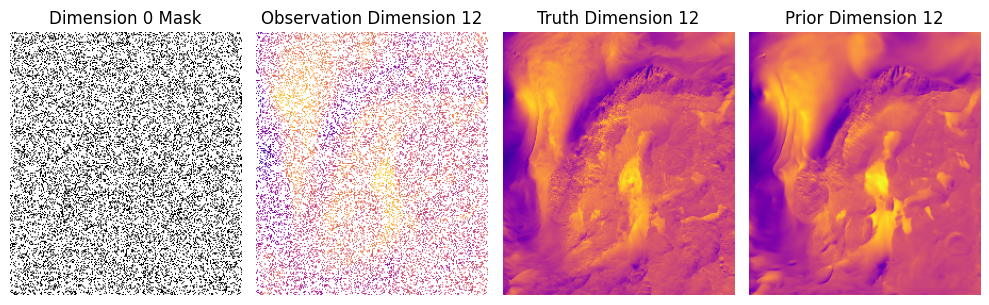

In [34]:
import matplotlib.pyplot as plt
import numpy as np
DIM=12
TIMESTEP=-1

# Visualize the observation mask
fig, axs = plt.subplots(1, 4, figsize=(10, 5))

# Plot the masks
im1 = axs[0].imshow(
    obs_mask.reshape(target_states.shape[0], GRID_SHAPE[0], GRID_SHAPE[1], -1)[0, ..., 0]
    .cpu()
    .numpy()
    .astype(np.float32),
    cmap="binary",
    origin="lower",
)
axs[0].set_title("Dimension 0 Mask")

# Second dimension - overlay mask
masked_data1 = (
    truth.reshape(target_states.shape[0], GRID_SHAPE[0], GRID_SHAPE[1], -1)[TIMESTEP, ..., DIM]
    .cpu()
    .numpy()
    .astype(np.float32)
)
# alpha must be float array (0..1) or scalar; convert boolean/int to float32
mask_viz1 = (
    obs_mask.reshape(target_states.shape[0], GRID_SHAPE[0], GRID_SHAPE[1], -1)[0, ..., 0]
    .cpu()
    .numpy()
    .astype(np.float32)
)

# Show the field and overlay mask as a semi-transparent layer
axs[1].imshow(masked_data1, cmap="plasma", origin="lower", alpha=mask_viz1*1.0)
axs[1].set_title(f"Observation Dimension {DIM}")

axs[2].imshow(masked_data1, cmap="plasma", origin="lower")
axs[2].set_title(f"Truth Dimension {DIM}")

axs[3].imshow(prior.reshape(prior.shape[0], prior.shape[1], GRID_SHAPE[0], GRID_SHAPE[1], -1)[TIMESTEP, 0, ..., DIM].cpu().numpy().astype(np.float32), cmap="plasma", origin="lower")
axs[3].set_title(f"Prior Dimension {DIM}")

for ax in axs:
    ax.set_aspect("equal")
    ax.axis("off")

plt.tight_layout()
plt.show()

In [35]:
# Main settings for the assimilation
observation_fn =  lambda x: x

obs = observation_fn(truth[:,obs_mask[0,:,0],:])
obs_noise = torch.randn_like(truth) * torch.tensor(args.obs_sigma) #, device=args.device)
obs = obs + observation_fn(obs_noise[:,obs_mask[0,:,0],:])

obs_plot = truth + obs_noise

In [36]:
from neural_lam.models.ess import ESS

assimilation_model = ESS(args)
init_states_ens = init_states.unsqueeze(0).expand(args.ensemble_size, -1, -1, -1).contiguous().to(device)

posteriors = []
with torch.no_grad():
    for i in range(target_states.shape[0]):
        posterior, log_like_list = assimilation_model.assimilate(prior, init_states_ens, forcing_ens[:, i], boundary_forcing_ens[:, i], obs[i], obs_mask, observation_fn, debug=True)
        posteriors.append(posterior)
        init_states_ens = torch.cat([init_states_ens[:, 1:], posterior.unsqueeze(1)], dim=1)

posterior = torch.stack(posteriors, dim=0)


grid_dim: 54
Attn at level 0 with res 268: False
Attn at level 0 with res 268: False
Attn at level 0 with res 268: False
Attn at level 0 with res 268: False
Channels at level 0: 128
res_down: tensor([134, 120], dtype=torch.int32)
Attn at level 1 with res 134: False
Attn at level 1 with res 134: False
Attn at level 1 with res 134: False
Attn at level 1 with res 134: False
Channels at level 1: 256
res_down: tensor([68, 60], dtype=torch.int32)
Attn at level 2 with res 68: False
Attn at level 2 with res 68: False
Attn at level 2 with res 68: False
Attn at level 2 with res 68: False
Channels at level 2: 256
res_down: tensor([34, 30], dtype=torch.int32)
Attn at level 3 with res 34: False
Attn at level 3 with res 34: False
Attn at level 3 with res 34: False
Attn at level 3 with res 34: False
Channels at level 3: 256


res_up: tensor([68, 60], dtype=torch.int32)
res_up: tensor([134, 120], dtype=torch.int32)
res_up: tensor([268, 238], dtype=torch.int32)


/proj/berzelius-2022-164/users/x_erila/neural-lam/neural_lam/models/ess.py:23: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  self.model.load_state_dict(torch.load(args.pretr

args.device: cuda
log_like: torch.Size([5])
batch_size: 5


2026-01-15 15:52:00 - Progress: 0.0% | MCMC steps: 0-1 | Time elapsed: 0:00:00 | ETA: Unknown | log_like: -115584.3984
2026-01-15 15:52:00 - Progress: 0.0% | MCMC steps: 0-2 | Time elapsed: 0:00:00 | ETA: Unknown | log_like: -115151.7500
2026-01-15 15:52:01 - Progress: 0.0% | MCMC steps: 0-3 | Time elapsed: 0:00:00 | ETA: Unknown | log_like: -115146.9766
2026-01-15 15:52:01 - Progress: 0.0% | MCMC steps: 0-4 | Time elapsed: 0:00:00 | ETA: Unknown | log_like: -115115.1797
2026-01-15 15:52:01 - Progress: 0.0% | MCMC steps: 0-5 | Time elapsed: 0:00:00 | ETA: Unknown | log_like: -115099.0000
2026-01-15 15:52:01 - Progress: 1.0% | MCMC steps: 1-5 | Time elapsed: 0:00:00 | ETA: 2026-01-15 15:53:40.074067 | log_like: -115098.6875
2026-01-15 15:52:01 - Progress: 1.0% | MCMC steps: 1-6 | Time elapsed: 0:00:01 | ETA: 2026-01-15 15:53:54.318780 | log_like: -115093.2500
2026-01-15 15:52:01 - Progress: 1.0% | MCMC steps: 1-6 | Time elapsed: 0:00:01 | ETA: 2026-01-15 15:54:08.547766 | log_like: -115

...

Debug: True
Log likelihood list length: 922


2026-01-15 16:00:53 - Starting sampling with batch size 5, total steps 101 (warmup: 100)
2026-01-15 16:00:53 - Progress: 0.0% | MCMC steps: 0-0 | Time elapsed: 0:00:00 | ETA: Unknown | log_like: -117686.3672
2026-01-15 16:00:53 - Progress: 0.0% | MCMC steps: 0-1 | Time elapsed: 0:00:00 | ETA: Unknown | log_like: -117647.3984


log_like: torch.Size([5])
batch_size: 5


2026-01-15 16:00:53 - Progress: 0.0% | MCMC steps: 0-1 | Time elapsed: 0:00:00 | ETA: Unknown | log_like: -117647.3984
2026-01-15 16:00:53 - Progress: 0.0% | MCMC steps: 0-2 | Time elapsed: 0:00:00 | ETA: Unknown | log_like: -117636.6797
2026-01-15 16:00:53 - Progress: 0.0% | MCMC steps: 0-2 | Time elapsed: 0:00:00 | ETA: Unknown | log_like: -117636.6797
2026-01-15 16:00:53 - Progress: 0.0% | MCMC steps: 0-2 | Time elapsed: 0:00:00 | ETA: Unknown | log_like: -117636.6797
2026-01-15 16:00:53 - Progress: 0.0% | MCMC steps: 0-2 | Time elapsed: 0:00:00 | ETA: Unknown | log_like: -117636.3750
2026-01-15 16:00:54 - Progress: 0.0% | MCMC steps: 0-2 | Time elapsed: 0:00:01 | ETA: Unknown | log_like: -117636.3750
2026-01-15 16:00:54 - Progress: 1.0% | MCMC steps: 1-2 | Time elapsed: 0:00:01 | ETA: 2026-01-15 16:03:02.423600 | log_like: -117634.6016
2026-01-15 16:00:54 - Progress: 1.0% | MCMC steps: 1-2 | Time elapsed: 0:00:01 | ETA: 2026-01-15 16:03:16.853512 | log_like: -117634.6016
2026-01-15

Debug: True
Log likelihood list length: 924


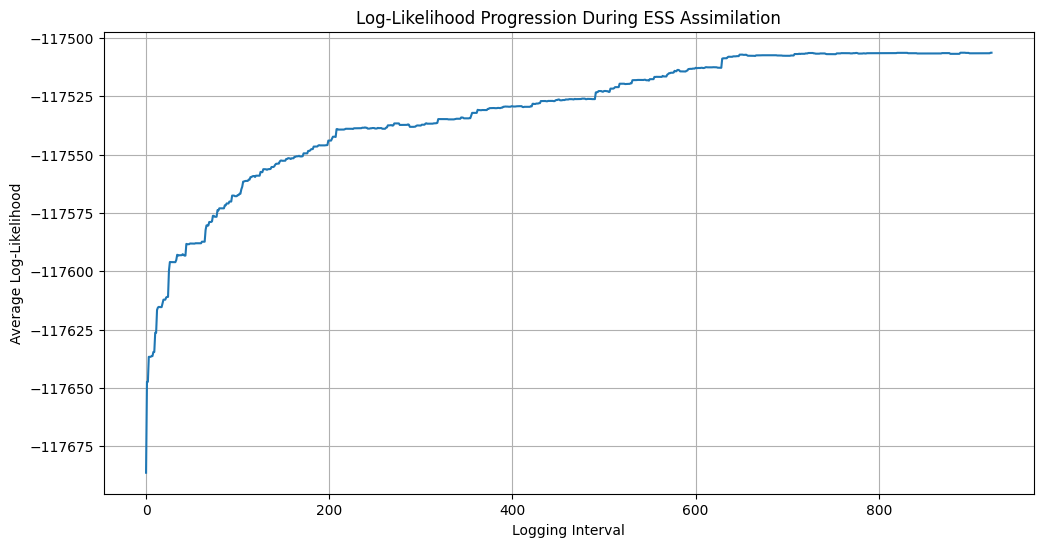

In [37]:
plt.figure(figsize=(12, 6))
plt.plot(log_like_list)
plt.xlabel('Logging Interval')
plt.ylabel('Average Log-Likelihood')
plt.title('Log-Likelihood Progression During ESS Assimilation')
plt.grid()
plt.show()

In [38]:
truth.shape, prior.shape, posterior.shape, obs_plot.shape

(torch.Size([5, 54064, 17]),
 torch.Size([5, 5, 54064, 17]),
 torch.Size([5, 5, 54064, 17]),
 torch.Size([5, 54064, 17]))

In [39]:
posterior.reshape(posterior.shape[0], posterior.shape[1], GRID_SHAPE[0], GRID_SHAPE[1], posterior.shape[-1]).shape

torch.Size([5, 5, 248, 218, 17])

In [40]:
plot_posterior = posterior.reshape(posterior.shape[0], posterior.shape[1], GRID_SHAPE[0], GRID_SHAPE[1], posterior.shape[-1])[TIMESTEP, ...,VAR_IDX]

plot_posterior.shape

torch.Size([5, 248, 218])

/tmp/ipykernel_1416013/3597402666.py:46: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  rmse = ((1*(torch.tensor(plot_posterior.to(device)) - torch.tensor(truth_plot.to(device)).unsqueeze(0))).pow(2).mean(dim=(1,2)).sqrt())
/tmp/ipykernel_1416013/3597402666.py:47: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  rmse_prior = ((1*(torch.tensor(prior_plot, device=device) - torch.tensor(truth_plot, device=device).unsqueeze(0))).pow(2).mean(dim=(1,2)).sqrt())
/tmp/ipykernel_1416013/3597402666.py:50: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  r

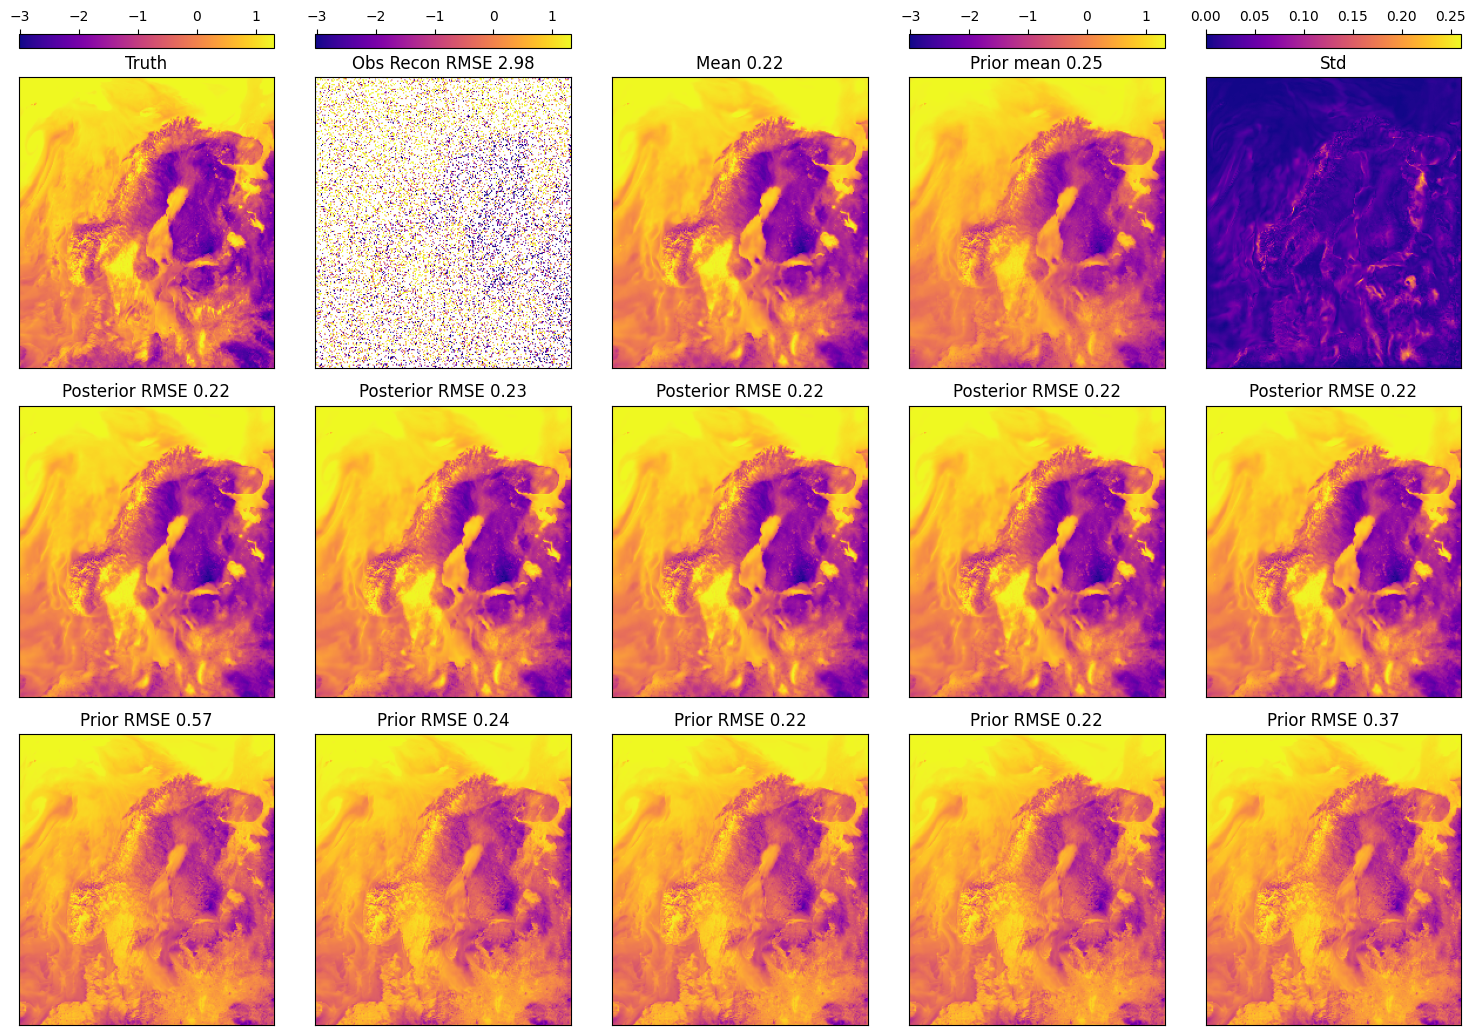

In [41]:
def plot_prior_posterior(truth, prior, posterior, obs_plot, obs_mask, TIMESTEP, VAR_IDX, plot_residual=False, plot_name='test'):
    for timestep in range(truth.shape[0]):
        for var_idx in range(truth.shape[-1]):
            truth_plot = truth.reshape(truth.shape[0], GRID_SHAPE[0], GRID_SHAPE[1], truth.shape[-1])[timestep, ...,var_idx]
            prior_plot = prior.reshape(prior.shape[0], prior.shape[1], GRID_SHAPE[0], GRID_SHAPE[1], prior.shape[-1])[timestep, ...,var_idx]
            plot_posterior = posterior.reshape(posterior.shape[0], posterior.shape[1], GRID_SHAPE[0], GRID_SHAPE[1], posterior.shape[-1])[timestep, ...,var_idx]
            plot_obs = obs_plot.reshape(obs_plot.shape[0], GRID_SHAPE[0], GRID_SHAPE[1], obs_plot.shape[-1])[timestep, ...,var_idx]

            # Plot results
            from mpl_toolkits.axes_grid1.inset_locator import inset_axes

            fig, axs = plt.subplots(3,5, figsize=(15,10))
            cmap  = 'plasma'#'jet'#sns.color_palette("icefire", as_cmap=True)
            #cmap  = sns.color_palette("icefire", as_cmap=True)

            gds = torch.linspace(0.0, 1.0, 6, device=device)
            indices = torch.linspace(0.0, 1.0, 6, device=device)

            ens_mean = posterior.mean(dim=0)

            if prior is None:
                prior_plot = torch.zeros_like(plot_posterior)
                prior_alpha = torch.zeros_like(obs_mask)
            else:
                prior_alpha = torch.ones_like(obs_mask)

            # if plot_residual:
            #     plot_prior = prior_plot - truth
            #     plot_posterior = posterior - truth
            #     plot_ens_mean = ens_mean - truth[0]

            #     vmin = plot_posterior[TIMESTEP, ...,VAR_IDX].min()
            #     vmax = plot_posterior[TIMESTEP, ...,VAR_IDX].max()
                
            #     vmin_prior = prior_plot[TIMESTEP, ...,VAR_IDX].min()
            #     vmax_prior = prior_plot[TIMESTEP, ...,VAR_IDX].max()
            # else:

            plot_ens_mean = plot_posterior.mean(dim=0)

            vmin = truth_plot.min()
            vmax = truth_plot.max()
            vmin_prior = vmin
            vmax_prior = vmax

            rmse = ((1*(torch.tensor(plot_posterior.to(device)) - torch.tensor(truth_plot.to(device)).unsqueeze(0))).pow(2).mean(dim=(1,2)).sqrt())
            rmse_prior = ((1*(torch.tensor(prior_plot, device=device) - torch.tensor(truth_plot, device=device).unsqueeze(0))).pow(2).mean(dim=(1,2)).sqrt())
            rmse_mean = ((1*(plot_posterior.to(device).mean(dim=0) - truth_plot.to(device))).pow(2).mean(dim=(0,1)).sqrt())
            rmse_prior_mean = ((1*(prior_plot.mean(dim=0) - truth_plot.to(device))).pow(2).mean(dim=(0,1)).sqrt())
            rmse_obs = ((1*(torch.tensor(plot_obs).to(device) - torch.tensor(truth_plot.to(device)).unsqueeze(0))).pow(2).mean(dim=(0,1,2)).sqrt()).item()
            def set_cbar(im):
                ax = im.axes
                # Create an inset axes for the colorbar above the plot
                cax = inset_axes(ax,
                                    width="100%",   # relative to ax width
                                    height="5%",   # relative to ax height
                                    loc='upper center',
                                    bbox_to_anchor=(0, 0.15, 1, 1),  # place above
                                    bbox_transform=ax.transAxes,
                                    borderpad=0)
                cbar = plt.colorbar(im, cax=cax, orientation='horizontal')
                cbar.ax.xaxis.set_ticks_position('top')
                cbar.ax.xaxis.set_label_position('top')

            # Define highlight_cell function
            def highlight_cell(obs_mask, ax=None, **kwargs):
                ax = ax or plt.gca()
                for i in range(obs_mask.shape[0]):      # rows
                    for j in range(obs_mask.shape[1]):  # columns
                        if obs_mask[i, j]:
                            rect = plt.Rectangle((j-0.5, i-0.5), 1, 1, fill=False, **kwargs)
                            ax.add_patch(rect)

            for i, ax in enumerate(axs.flat):
                ax.set_aspect('equal')
                if i == 0:
                    im = ax.imshow(truth_plot.cpu().detach().numpy(), cmap=cmap, vmin=vmin, vmax=vmax, origin="lower")
                    ax.set_title('Truth', fontsize=12)
                    set_cbar(im)
                elif i ==1:
                    im = ax.imshow(plot_obs.cpu().detach().numpy(), cmap=cmap, vmin=vmin, vmax=vmax, alpha=mask_viz1*1.0, origin="lower")
                    set_cbar(im)
                    ax.set_title(f'Obs Recon RMSE {rmse_obs:.2f}', fontsize=12)
                elif i ==2:
                    ax.imshow((plot_ens_mean).cpu().detach().numpy(), cmap=cmap, vmin=vmin, vmax=vmax, origin="lower")
                    ax.set_title(f'Mean {rmse_mean:.2f}', fontsize=12)
                elif i ==3:
                    im = ax.imshow((prior_plot.mean(dim=0)).cpu().detach().numpy(), cmap=cmap, vmin=vmin, vmax=vmax, origin="lower")
                    set_cbar(im)
                    ax.set_title(f'Prior mean {rmse_prior_mean:.2f}', fontsize=12)
                elif i ==4:
                    im = ax.imshow((plot_posterior).std(dim=0).cpu().detach().numpy(), cmap=cmap, vmin=0, origin="lower")
                    ax.set_title('Std', fontsize=12)
                    set_cbar(im)
                elif i < 10:
                    ax.imshow((((plot_posterior)[i-5])).cpu().detach().numpy(), cmap=cmap, vmin=vmin, vmax=vmax, origin="lower")
                    ax.set_title(f'Posterior RMSE {rmse[i-5].item():.2f}', fontsize=12)
                else:
                    ax.imshow(((prior_plot[int(indices[i-10])])).cpu().detach().numpy(), cmap=cmap, vmin=vmin, vmax=vmax, origin="lower")
                    ax.set_title(f'Prior RMSE {rmse_prior[i-10].item():.2f}', fontsize=12)
                
                ax.yaxis.set_visible(False)
                ax.xaxis.set_visible(False)
            if plot_name != 'test':
                os.makedirs(f'assim_plots/{plot_name}', exist_ok=True)
                plt.savefig(f'assim_plots/{plot_name}/t{timestep}_var_{var_idx}.png')
            if timestep == TIMESTEP and var_idx == VAR_IDX:
                plt.tight_layout()
                plt.show()
            else:
                plt.close()

TIMESTEP = 0  # choose which timestep to plot
VAR_IDX = 4  # choose which variable to plot
plot_name='obs_25_sigma_3_ESS'
plot_prior_posterior(truth, prior, posterior, obs_plot, obs_mask, TIMESTEP, VAR_IDX, plot_residual=False, plot_name=plot_name)

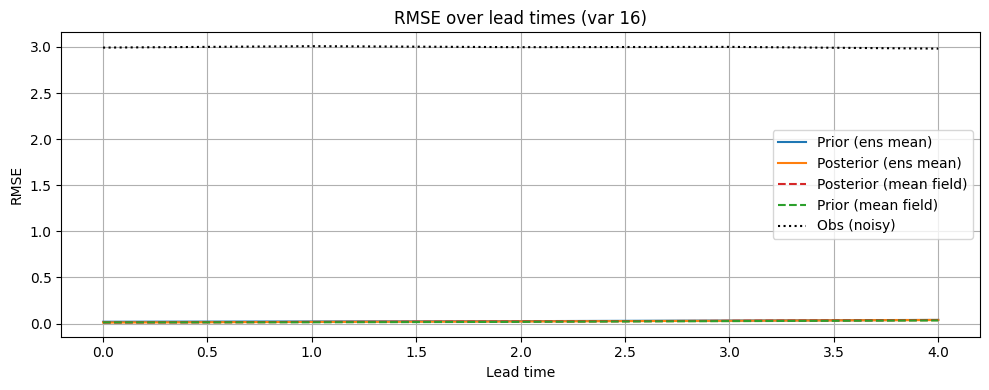

RMSE prior mean final lead time: 0.0338
RMSE posterior mean final lead time: 0.0385
RMSE obs final lead time: 2.9817


In [42]:
# choose variable index if not set
VAR_IDX = 16

# move to device and extract variable
truth_var = truth[..., VAR_IDX].to(device)                # (T, N)
prior_var = prior[..., VAR_IDX].to(device) if prior is not None else None  # (T, n_ens, N)
posterior_var = posterior[..., VAR_IDX].to(device)   # (T, n_ens, N)
obs_var = obs_plot[..., VAR_IDX].to(device)               # (T, N)

T = truth_var.shape[0]
leads = np.arange(T)

# RMSE per-ensemble member and time
if prior_var is not None:
    # prior_var expected shape (T, n_ens, N)
    rmse_prior_per_ens = ((prior_var - truth_var.unsqueeze(1))**2).mean(dim=2).sqrt()  # (T, n_ens)
    rmse_prior_mean = rmse_prior_per_ens.mean(dim=1)   # (T,)
    rmse_prior_std = rmse_prior_per_ens.std(dim=1)
    rmse_prior_meanfield = ((prior_var.mean(dim=1) - truth_var)**2).mean(dim=1).sqrt()  # (T,)
else:
    rmse_prior_per_ens = None
    rmse_prior_mean = None
    rmse_prior_std = None
    rmse_prior_meanfield = None

# posterior
rmse_post_per_ens = ((posterior_var - truth_var.unsqueeze(1))**2).mean(dim=2).sqrt()  # (T, n_ens)
rmse_post_mean = rmse_post_per_ens.mean(dim=1)
rmse_post_std = rmse_post_per_ens.std(dim=1)
rmse_post_meanfield = ((posterior_var.mean(dim=1) - truth_var)**2).mean(dim=1).sqrt()

# observations (noisy truth in obs_plot) RMSE per time
rmse_obs_time = ((obs_var - truth_var)**2).mean(dim=1).sqrt()  # (T,)

# plot
plt.figure(figsize=(10,4))
if rmse_prior_mean is not None:
    plt.plot(leads, rmse_prior_mean.cpu().numpy(), label='Prior (ens mean)')
    plt.fill_between(leads,
                     (rmse_prior_mean - rmse_prior_std).cpu().numpy(),
                     (rmse_prior_mean + rmse_prior_std).cpu().numpy(),
                     alpha=0.2)

plt.plot(leads, rmse_post_mean.cpu().numpy(), label='Posterior (ens mean)', color='C1')
plt.fill_between(leads,
                 (rmse_post_mean - rmse_post_std).cpu().numpy(),
                 (rmse_post_mean + rmse_post_std).cpu().numpy(),
                 alpha=0.2, color='C1')

plt.plot(leads, rmse_post_meanfield.cpu().numpy(), '--', label='Posterior (mean field)', color='C3')
if rmse_prior_meanfield is not None:
    plt.plot(leads, rmse_prior_meanfield.cpu().numpy(), '--', label='Prior (mean field)', color='C2')

plt.plot(leads, rmse_obs_time.cpu().numpy(), ':', label='Obs (noisy)', color='k')

plt.xlabel('Lead time')
plt.ylabel('RMSE')
plt.title(f'RMSE over lead times (var {VAR_IDX})')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

print(f"RMSE prior mean final lead time: {rmse_prior_meanfield[-1].item():.4f}")
print(f"RMSE posterior mean final lead time: {rmse_post_meanfield[-1].item():.4f}")
print(f"RMSE obs final lead time: {rmse_obs_time[-1].item():.4f}")

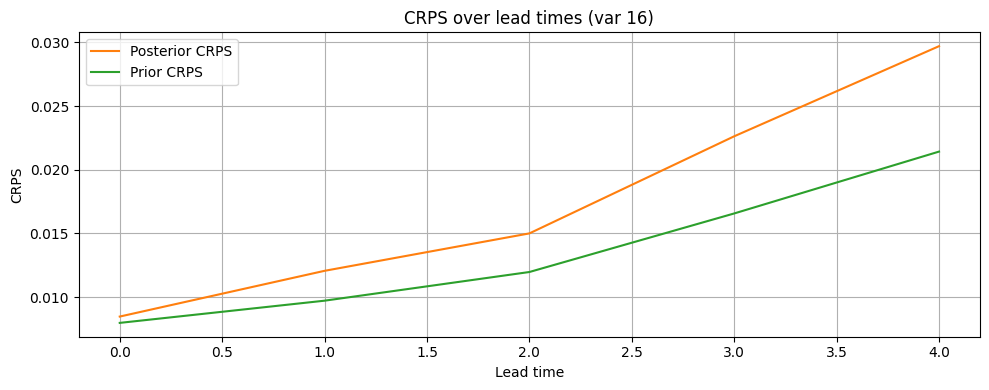

CRPS prior mean final lead time: 0.0214
CRPS posterior mean final lead time: 0.0297


In [25]:
def ensemble_crps(ens, truth):
    # ens: (T, M, N), truth: (T, N)
    M = ens.shape[1]
    # term1: mean |x_i - y| over ensemble members -> (T, N)
    term1 = torch.mean(torch.abs(ens - truth.unsqueeze(1)), dim=1)
    # term2: 0.5 * mean_{i,j} |x_i - x_j| -> (T, N)
    if M > 1:
        diffs = torch.abs(ens.unsqueeze(2) - ens.unsqueeze(1))  # (T, M, M, N)
        term2 = 0.5 * diffs.mean(dim=(1, 2))
    else:
        term2 = torch.zeros_like(term1)
    crps_field = term1 - term2  # (T, N)
    # average over grid points -> (T,)
    return crps_field.mean(dim=1)

# ensure data on same device
truth_var_d = truth_var.to(device)
posterior_var_d = posterior_var.to(device)
prior_var_d = prior_var.to(device) if prior_var is not None else None

crps_post_time = ensemble_crps(posterior_var_d, truth_var_d)  # (T,)
crps_prior_time = ensemble_crps(prior_var_d, truth_var_d) if prior_var_d is not None else None

# move to cpu numpy for plotting
crps_post_np = crps_post_time.cpu().numpy()
crps_prior_np = crps_prior_time.cpu().numpy() if crps_prior_time is not None else None

# plot CRPS over lead times
plt.figure(figsize=(10,4))
plt.plot(leads, crps_post_np, label='Posterior CRPS', color='C1')
if crps_prior_np is not None:
    plt.plot(leads, crps_prior_np, label='Prior CRPS', color='C2')
plt.xlabel('Lead time')
plt.ylabel('CRPS')
plt.title(f'CRPS over lead times (var {VAR_IDX})')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

print(f"CRPS prior mean final lead time: {crps_prior_np[-1]:.4f}" if crps_prior_np is not None else "No prior CRPS computed")
print(f"CRPS posterior mean final lead time: {crps_post_np[-1]:.4f}")

# Training on one observation

In [37]:
import gc

gc.collect()
torch.cuda.empty_cache()

In [ ]:
model_train = CRPS(args).to(args.device)
model_train.load_state_dict(torch.load(args.pretrained_model_path,map_location=args.device)["state_dict"])

# init_z per ensemble member, make it trainable
init_z = torch.randn(init_states_ens.shape[0], model_train.model.noise_dim, device=device, requires_grad=True)

/proj/berzelius-2022-164/users/x_erila/neural-lam/neural_lam/utils.py:49: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  return torch.load(


grid_dim: 54
Attn at level 0 with res 268: False
Attn at level 0 with res 268: False
Attn at level 0 with res 268: False
Attn at level 0 with res 268: False
Channels at level 0: 128
res_down: tensor([134, 120], dtype=torch.int32)
Attn at level 1 with res 134: False
Attn at level 1 with res 134: False
Attn at level 1 with res 134: False
Attn at level 1 with res 134: False
Channels at level 1: 256
res_down: tensor([68, 60], dtype=torch.int32)
Attn at level 2 with res 68: False
Attn at level 2 with res 68: False
Attn at level 2 with res 68: False
Attn at level 2 with res 68: False
Channels at level 2: 256
res_down: tensor([34, 30], dtype=torch.int32)
Attn at level 3 with res 34: False
Attn at level 3 with res 34: False
Attn at level 3 with res 34: False
Attn at level 3 with res 34: False
Channels at level 3: 256
res_up: tensor([68, 60], dtype=torch.int32)
res_up: tensor([134, 120], dtype=torch.int32)
res_up: tensor([268, 238], dtype=torch.int32)


/tmp/ipykernel_1350498/2068261693.py:2: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model_train.load_state_dict(torch.load(args.pretrained_model_path,map_location=args.dev

In [ ]:
from torch.nn import functional as F

l2_weight = 0

mask = obs_mask[0].to(device)  # shape: [state_dim, H, W]
target_flat = obs.view(-1).to(device)  # flatten observed values (N_obs,)

opt = torch.optim.Adam([init_z], lr=1e-4)

n_epochs = 500
for epoch in range(n_epochs):
    opt.zero_grad()
    # forward
    prev_prev_state = init_states_ens[:, 0]
    prev_state = init_states_ens[:, 1]
    posterior_train, _ = model_train.predict_step(
                        prev_state, prev_prev_state, forcing_ens[:, 0], boundary_forcing_ens[:, 0], init_z)
    # loss only on observed pixels + small regularizer on init_z
    mse = F.mse_loss(truth, posterior)
    l2 = (init_z**2).mean()
    loss = mse + l2_weight * l2


    loss.backward()
    opt.step()
    if epoch == 0:
        print(f"Initial loss: {loss.item():.6f} | mse {mse.item():.6f} | l2 {l2.item():.6e}")
        prior_train = posterior_train.detach()

    if epoch % 50 == 0 or epoch == n_epochs-1:
        print(f"epoch {epoch:4d} | loss {loss.item():.6f} | mse {mse.item():.6f} | l2 {l2.item():.6e}")

OutOfMemoryError: CUDA out of memory. Tried to allocate 156.00 MiB. GPU 0 has a total capacity of 79.25 GiB of which 73.94 MiB is free. Including non-PyTorch memory, this process has 79.17 GiB memory in use. Of the allocated memory 78.02 GiB is allocated by PyTorch, and 665.74 MiB is reserved by PyTorch but unallocated. If reserved but unallocated memory is large try setting PYTORCH_CUDA_ALLOC_CONF=expandable_segments:True to avoid fragmentation.  See documentation for Memory Management  (https://pytorch.org/docs/stable/notes/cuda.html#environment-variables)

In [ ]:
# l2_weight = 0

# mask = obs_mask[0].to(device)  # shape: [state_dim, H, W]
# target_flat = obs.view(-1).to(device)  # flatten observed values (N_obs,)

# prev_prev_state_opt = init_states_ens[:, 0].clone().detach().requires_grad_(True)
# prev_state_opt = init_states_ens[:, 1].clone().detach().requires_grad_(True)
# forcing_ens_opt = forcing_ens[:, 0].clone().detach().requires_grad_(True)
# boundary_forcing_ens_opt = boundary_forcing_ens[:, 0].clone().detach().requires_grad_(True)


# opt = torch.optim.Adam([init_z, prev_prev_state_opt, prev_state_opt, forcing_ens_opt, boundary_forcing_ens_opt], lr=1e-3)

# n_epochs = 500
# for epoch in range(n_epochs):
#     opt.zero_grad()
#     # forward
#     prev_prev_state = init_states_ens[:, 0]
#     prev_state = init_states_ens[:, 1]
#     posterior, _ = model.predict_step(
#                         prev_state_opt, prev_prev_state_opt, forcing_ens_opt, boundary_forcing_ens_opt, init_z)
#     # loss only on observed pixels + small regularizer on init_z
#     mse = F.mse_loss(truth, posterior)
#     l2 = (init_z**2).mean()
#     loss = mse + l2_weight * l2


#     loss.backward()
#     opt.step()

#     if epoch % 50 == 0 or epoch == n_epochs-1:
#         print(f"epoch {epoch:4d} | loss {loss.item():.6f} | mse {mse.item():.6f} | l2 {l2.item():.6e}")

In [39]:
posterior_train.shape, prior_train.shape, truth.shape

(torch.Size([5, 54064, 17]),
 torch.Size([5, 54064, 17]),
 torch.Size([1, 54064, 17]))

In [ ]:
F.mse_loss(truth, prior_train[0]), F.mse_loss(truth, posterior_train)

/tmp/ipykernel_1350498/3347345004.py:1: UserWarning: Using a target size (torch.Size([54064, 17])) that is different to the input size (torch.Size([1, 54064, 17])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  F.mse_loss(truth, prior_train[0]), F.mse_loss(truth, posterior_train)
/tmp/ipykernel_1350498/3347345004.py:1: UserWarning: Using a target size (torch.Size([5, 54064, 17])) that is different to the input size (torch.Size([1, 54064, 17])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  F.mse_loss(truth, prior_train[0]), F.mse_loss(truth, posterior_train)


(tensor(0.8225, device='cuda:0'),
 tensor(0.8405, device='cuda:0', grad_fn=<MseLossBackward0>))

In [ ]:
posterior_train = posterior_train.unsqueeze(0)
prior_train = prior_train.unsqueeze(0)

/tmp/ipykernel_1350498/4010283154.py:46: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  rmse = ((1*(torch.tensor(plot_posterior.to(device)) - torch.tensor(truth_plot.to(device)).unsqueeze(0))).pow(2).mean(dim=(1,2)).sqrt())
/tmp/ipykernel_1350498/4010283154.py:47: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  rmse_prior = ((1*(torch.tensor(prior_plot, device=device) - torch.tensor(truth_plot, device=device).unsqueeze(0))).pow(2).mean(dim=(1,2)).sqrt())
/tmp/ipykernel_1350498/4010283154.py:50: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  r

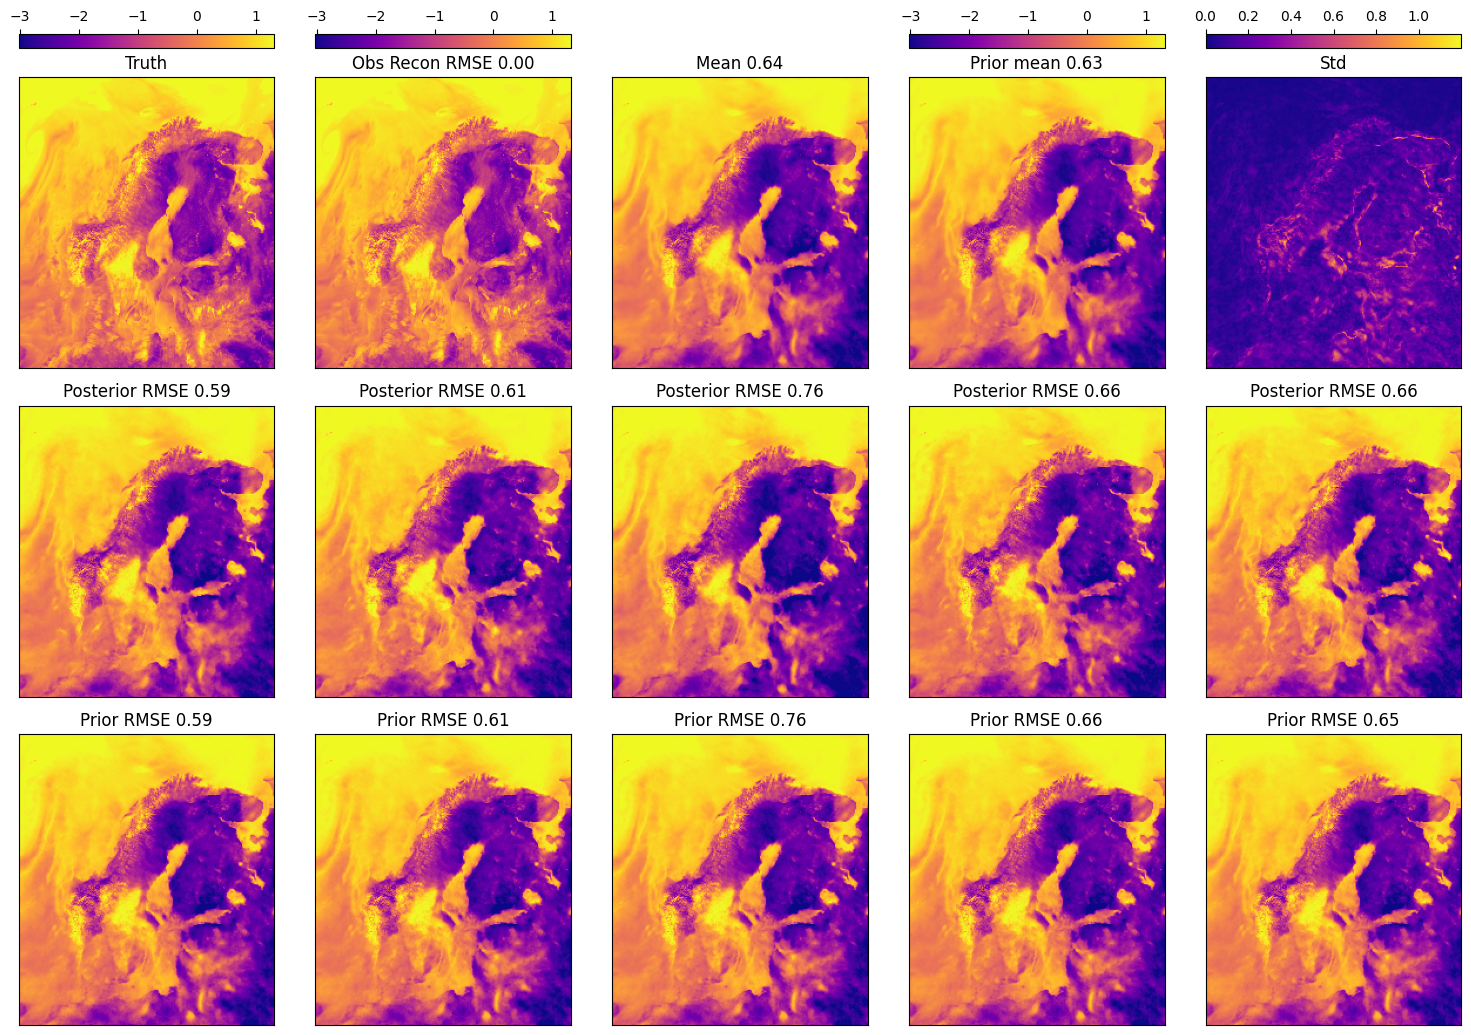

In [ ]:
TIMESTEP = 0  # choose which timestep to plot
VAR_IDX = 4  # choose which variable to plot
plot_name='obs_GT_train'

plot_prior_posterior(truth, prior_train, posterior_train, obs_plot, obs_mask, TIMESTEP, VAR_IDX, plot_residual=False, plot_name=plot_name)
# TIMESTEP = -1  # choose which timestep to plot
# VAR_IDX = 4  # choose which variable to plot
# plot_residual=False
# plot_name='test'

# truth_plot = truth.reshape(truth.shape[0], GRID_SHAPE[0], GRID_SHAPE[1], truth.shape[-1])[TIMESTEP, ...,VAR_IDX]
# prior_plot = prior_train.reshape(prior_train.shape[0], prior_train.shape[1], GRID_SHAPE[0], GRID_SHAPE[1], prior_train.shape[-1])[TIMESTEP, ...,VAR_IDX]
# plot_posterior = posterior_train.reshape(posterior_train.shape[0], posterior_train.shape[1], GRID_SHAPE[0], GRID_SHAPE[1], posterior_train.shape[-1])[TIMESTEP, ...,VAR_IDX]
# plot_obs = obs_plot.reshape(obs_plot.shape[0], GRID_SHAPE[0], GRID_SHAPE[1], obs_plot.shape[-1])[TIMESTEP, ...,VAR_IDX]

# # Plot results
# from mpl_toolkits.axes_grid1.inset_locator import inset_axes

# fig, axs = plt.subplots(3,5, figsize=(15,10))
# cmap  = 'plasma'#'jet'#sns.color_palette("icefire", as_cmap=True)
# #cmap  = sns.color_palette("icefire", as_cmap=True)

# gds = torch.linspace(0.0, 1.0, 6, device=device)
# indices = torch.linspace(0.0, 1.0, 6, device=device)

# ens_mean = posterior.mean(dim=0)

# if prior is None:
#     prior_plot = torch.zeros_like(plot_posterior)
#     prior_alpha = torch.zeros_like(obs_mask)
# else:
#     prior_alpha = torch.ones_like(obs_mask)

# # if plot_residual:
# #     plot_prior = prior_plot - truth
# #     plot_posterior = posterior - truth
# #     plot_ens_mean = ens_mean - truth[0]

# #     vmin = plot_posterior[TIMESTEP, ...,VAR_IDX].min()
# #     vmax = plot_posterior[TIMESTEP, ...,VAR_IDX].max()
    
# #     vmin_prior = prior_plot[TIMESTEP, ...,VAR_IDX].min()
# #     vmax_prior = prior_plot[TIMESTEP, ...,VAR_IDX].max()
# # else:

# plot_ens_mean = plot_posterior.mean(dim=0)

# vmin = truth_plot.min()
# vmax = truth_plot.max()
# vmin_prior = vmin
# vmax_prior = vmax

# rmse = ((1*(torch.tensor(plot_posterior.to(device)) - torch.tensor(truth_plot.to(device)).unsqueeze(0))).pow(2).mean(dim=(1,2)).sqrt())
# rmse_prior = ((1*(torch.tensor(prior_plot, device=device) - torch.tensor(truth_plot, device=device).unsqueeze(0))).pow(2).mean(dim=(1,2)).sqrt())
# rmse_mean = ((1*(plot_posterior.to(device).mean(dim=0) - truth_plot.to(device))).pow(2).mean(dim=(0,1)).sqrt())
# rmse_prior_mean = ((1*(prior_plot.mean(dim=0) - truth_plot.to(device))).pow(2).mean(dim=(0,1)).sqrt())
# rmse_obs = ((1*(torch.tensor(plot_obs).to(device) - torch.tensor(truth_plot.to(device)).unsqueeze(0))).pow(2).mean(dim=(0,1,2)).sqrt()).item()
# def set_cbar(im):
#     ax = im.axes
#     # Create an inset axes for the colorbar above the plot
#     cax = inset_axes(ax,
#                         width="100%",   # relative to ax width
#                         height="5%",   # relative to ax height
#                         loc='upper center',
#                         bbox_to_anchor=(0, 0.15, 1, 1),  # place above
#                         bbox_transform=ax.transAxes,
#                         borderpad=0)
#     cbar = plt.colorbar(im, cax=cax, orientation='horizontal')
#     cbar.ax.xaxis.set_ticks_position('top')
#     cbar.ax.xaxis.set_label_position('top')

# # Define highlight_cell function
# def highlight_cell(obs_mask, ax=None, **kwargs):
#     ax = ax or plt.gca()
#     for i in range(obs_mask.shape[0]):      # rows
#         for j in range(obs_mask.shape[1]):  # columns
#             if obs_mask[i, j]:
#                 rect = plt.Rectangle((j-0.5, i-0.5), 1, 1, fill=False, **kwargs)
#                 ax.add_patch(rect)

# for i, ax in enumerate(axs.flat):
#     ax.set_aspect('equal')
#     if i == 0:
#         im = ax.imshow(truth_plot.cpu().detach().numpy(), cmap=cmap, vmin=vmin, vmax=vmax, origin="lower")
#         ax.set_title('Truth', fontsize=12)
#         set_cbar(im)
#     elif i ==1:
#         im = ax.imshow(plot_obs.cpu().detach().numpy(), cmap=cmap, vmin=vmin, vmax=vmax, alpha=mask_viz1*1.0, origin="lower")
#         set_cbar(im)
#         ax.set_title(f'Obs Recon RMSE {rmse_obs:.2f}', fontsize=12)
#     elif i ==2:
#         ax.imshow((plot_ens_mean).cpu().detach().numpy(), cmap=cmap, vmin=vmin, vmax=vmax, origin="lower")
#         ax.set_title(f'Mean {rmse_mean:.2f}', fontsize=12)
#     elif i ==3:
#         im = ax.imshow((prior_plot.mean(dim=0)).cpu().detach().numpy(), cmap=cmap, vmin=vmin, vmax=vmax, origin="lower")
#         set_cbar(im)
#         ax.set_title(f'Prior mean {rmse_prior_mean:.2f}', fontsize=12)
#     elif i ==4:
#         im = ax.imshow((plot_posterior).std(dim=0).cpu().detach().numpy(), cmap=cmap, vmin=0, origin="lower")
#         ax.set_title('Std', fontsize=12)
#         set_cbar(im)
#     elif i < 10:
#         ax.imshow((((plot_posterior)[i-5])).cpu().detach().numpy(), cmap=cmap, vmin=vmin, vmax=vmax, origin="lower")
#         ax.set_title(f'Posterior RMSE {rmse[i-5].item():.2f}', fontsize=12)
#     else:
#         ax.imshow(((prior_plot[int(indices[i-10])])).cpu().detach().numpy(), cmap=cmap, vmin=vmin, vmax=vmax, origin="lower")
#         ax.set_title(f'Prior RMSE {rmse_prior[i-10].item():.2f}', fontsize=12)
    
#     ax.yaxis.set_visible(False)
#     ax.xaxis.set_visible(False)
# plt.tight_layout()
# if plot_name != 'test':
#     plt.savefig(f'{plot_name}.png')